In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve


In [2]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
from sklearn.metrics import accuracy_score

class KNN(BaseEstimator, ClassifierMixin):
    def __init__(self, k=3):
        self.k = k
    
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def predict(self, X):
        return np.array([self._predict(x) for x in np.array(X)])
    
    def _predict(self, x):
        distances = np.linalg.norm(self.X_train - x, axis=1)
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_indices]
        values, counts = np.unique(k_nearest_labels, return_counts=True)
        return values[np.argmax(counts)]

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


In [3]:
# GENERATING SOME RANDOM DATASET
np.random.seed(42)
X = np.random.randn(100, 2) 
y = np.random.choice([0, 1], size=100)  

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [5]:
knn = KNN(k=3)
knn.fit(X_train, y_train)

KNN()

In [6]:
y_train_pred = knn.predict(X_train)
y_val_pred = knn.predict(X_val)
y_test_pred = knn.predict(X_test)

In [7]:
train_accuracy_knn = accuracy_score(y_train, y_train_pred)
val_accuracy_knn = accuracy_score(y_val, y_val_pred)
test_accuracy_knn = accuracy_score(y_test, y_test_pred)

In [8]:
print("KNN Model Accuracy:")
print(f"Train Accuracy: {train_accuracy_knn:}")
print(f"Validation Accuracy: {val_accuracy_knn:}")
print(f"Test Accuracy: {test_accuracy_knn:}")

KNN Model Accuracy:
Train Accuracy: 0.8
Validation Accuracy: 0.5
Test Accuracy: 0.55


In [9]:
generalization_gap_knn = train_accuracy_knn - test_accuracy_knn
print(f"\nGeneralization Gap: {generalization_gap_knn:.4f}")


Generalization Gap: 0.2500


In [10]:
train_sizes, train_scores, val_scores = learning_curve(knn, X_train, y_train, cv=5, n_jobs=-1)

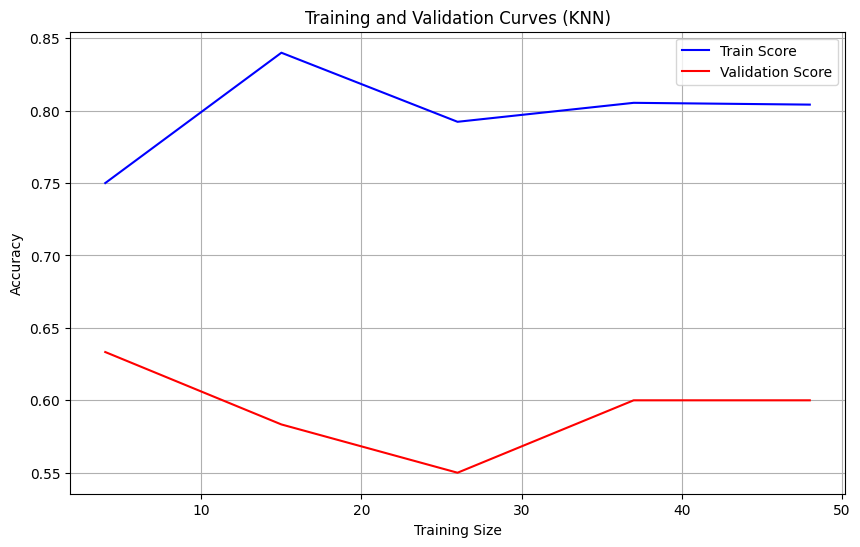

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score', color='blue')
plt.plot(train_sizes, np.mean(val_scores, axis=1), label='Validation Score', color='red')
plt.title('Training and Validation Curves (KNN)')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


In [12]:
k_values = [1, 3, 5, 7, 9]
train_errors, val_errors = [], []

In [13]:
for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    train_pred = knn.predict(X_train)
    val_pred = knn.predict(X_val)
    train_errors.append(1 - accuracy_score(y_train, train_pred))
    val_errors.append(1 - accuracy_score(y_val, val_pred))

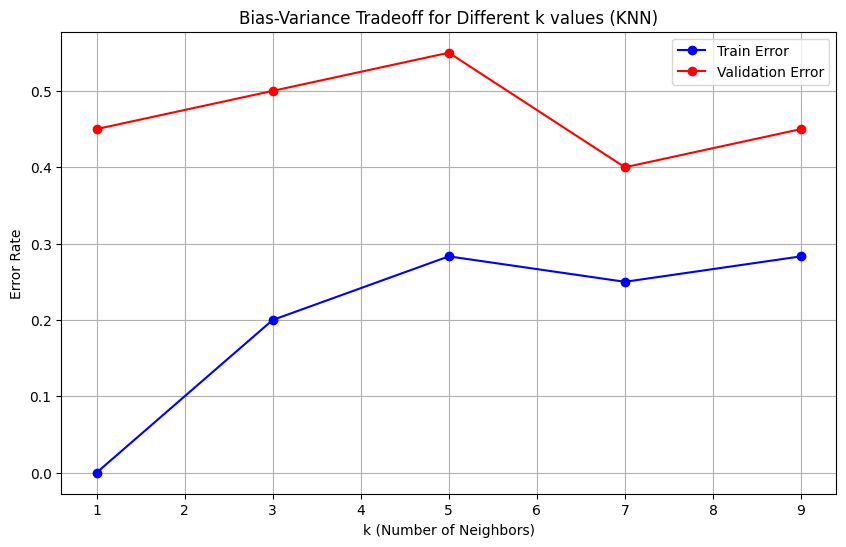

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, label='Train Error', color='blue', marker='o')
plt.plot(k_values, val_errors, label='Validation Error', color='red', marker='o')
plt.title('Bias-Variance Tradeoff for Different k values (KNN)')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)

In [15]:
print("\nFrom the learning curves and error plots, we can observe:")
print("1. A smaller k value can lead to overfitting (high variance).")
print("2. A larger k value might result in underfitting (high bias).")


From the learning curves and error plots, we can observe:
1. A smaller k value can lead to overfitting (high variance).
2. A larger k value might result in underfitting (high bias).
